In [28]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [29]:
train_dataset = torchvision.datasets.MNIST(
    root='.',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

In [30]:
train_dataset.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [31]:
#Use max to make sure that there are white values
train_dataset.data.max()

tensor(255, dtype=torch.uint8)

In [32]:
#Targets
train_dataset.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [33]:
#Download test dataset
test_dataset = torchvision.datasets.MNIST(
    root = '.',
    train = False,
    transform=transforms.ToTensor(),
    download=True
)
test_dataset.data.shape

torch.Size([10000, 28, 28])

In [34]:
#Build model
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128,10)
)

In [35]:
#Device for apple MPS
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(device)
model.to(device)

mps


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

In [36]:
#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [37]:
# Create DataLoaders for training and testing datasets

batch_size = 128

# Training DataLoader: shuffles data for better training
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=batch_size
)

# Testing DataLoader: no shuffling, maintains order for evaluation
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=batch_size
)

In [38]:
#Check what data loader does
tmp_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=1, shuffle=True)

for x, y in tmp_loader:
    print(x)
    print(x.shape)
    print(y.shape)
    break
    

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2196, 0.9412,
           0.6627, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0196, 0.8510, 0.9529,
           0.2353, 0.0000, 0.0000, 0.0000, 

In [44]:
# Train the model

# Number of times to go through the entire training dataset
epochs = 10

# Arrays to keep track of loss values for each epoch
train_losses = np.zeros(epochs)
test_losses = np.zeros(epochs)

# Loop through each epoch
for i in range(epochs):
    train_loss = []  # To store training losses in this epoch

    # Go through the training data in batches
    for inputs, targets in train_loader:
        # Move data to GPU (if available)
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Flatten the input images (from 28x28 to 784)
        inputs = inputs.view(-1, 784)

        # Reset the gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: make predictions
        outputs = model(inputs)

        # Calculate the loss between predictions and actual labels
        loss = criterion(outputs, targets)

        # Backward pass: compute gradients
        loss.backward()

        # Update the weights
        optimizer.step()

        # Save the loss for this batch
        train_loss.append(loss.item())

    # Calculate the average training loss for this epoch
    train_loss = np.mean(train_loss)

    test_loss = []  # To store testing losses in this epoch

    # Go through the test data in batches
    for inputs, targets in test_loader:
        # Move data to GPU (if available)
        inputs, targets = inputs.to(device), targets.to(device)

        # Flatten the input images
        inputs = inputs.view(-1, 784)

        # No need to zero gradients or backprop during testing

        # Forward pass: make predictions
        outputs = model(inputs)

        # Calculate the loss
        loss = criterion(outputs, targets)

        # Save the loss for this batch
        test_loss.append(loss.item())

    # Calculate the average test loss for this epoch
    test_loss = np.mean(test_loss)

    # Save the losses for plotting later
    train_losses[i] = train_loss
    test_losses[i] = test_loss

    # Print the losses for this epoch
    print(f'Epoch: {i+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch: 1/10, Train Loss: 0.0319, Test Loss: 0.0719
Epoch: 2/10, Train Loss: 0.0274, Test Loss: 0.0691
Epoch: 3/10, Train Loss: 0.0235, Test Loss: 0.0702
Epoch: 4/10, Train Loss: 0.0202, Test Loss: 0.0737
Epoch: 5/10, Train Loss: 0.0175, Test Loss: 0.0747
Epoch: 6/10, Train Loss: 0.0149, Test Loss: 0.0720
Epoch: 7/10, Train Loss: 0.0128, Test Loss: 0.0758
Epoch: 8/10, Train Loss: 0.0107, Test Loss: 0.0739
Epoch: 9/10, Train Loss: 0.0094, Test Loss: 0.0785
Epoch: 10/10, Train Loss: 0.0079, Test Loss: 0.0761


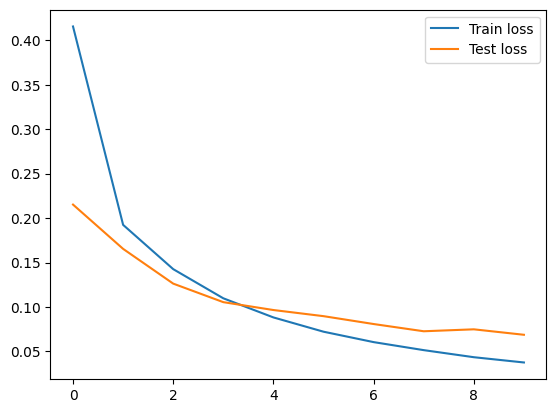

In [40]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_losses, label = 'Test loss')
plt.legend()
plt.show()

In [45]:
# Evaluate model accuracy on training and test sets

# -------- Training Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in train_loader:
    # Move data to device (CPU or GPU)
    inputs, targets = inputs.to(device), targets.to(device)

    # Flatten input images (28x28 -> 784)
    inputs = inputs.view(-1, 784)

    # Get model predictions
    outputs = model(inputs)

    # Get predicted class (highest score)
    _, predictions = torch.max(outputs, 1)

    # Count correct predictions
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate training accuracy
train_acc = n_correct / n_total

# -------- Testing Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    inputs = inputs.view(-1, 784)
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate test accuracy
test_acc = n_correct / n_total

# Print results
print(f'Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}')


Train acc: 0.9994, Test acc: 0.9787


In [49]:
# Plot confusion matrix for classification results
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots a confusion matrix.

    Parameters:
    - cm: confusion matrix (2D array)
    - classes: list of class labels
    - normalize: whether to normalize values
    - title: title of the plot
    - cmap: color map used for the plot
    """
    
    # Normalize the matrix if requested
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')

    print(cm)

    # Display the matrix as an image
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Set up tick marks and labels
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Format each cell
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    # Final layout settings
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion matrix without normalization
[[ 969    0    1    1    1    1    2    1    3    1]
 [   0 1125    2    1    0    0    1    1    5    0]
 [   3    4 1005    3    3    0    3    4    6    1]
 [   0    0    7  991    0    4    0    2    0    6]
 [   0    1    2    1  965    2    4    1    0    6]
 [   2    0    0    9    0  868    6    0    4    3]
 [   6    2    2    1    6    4  934    0    3    0]
 [   1    3   10    2    1    0    0 1004    1    6]
 [   7    1    3    7    2    8    1    3  937    5]
 [   0    2    0    1    8    4    0    3    2  989]]


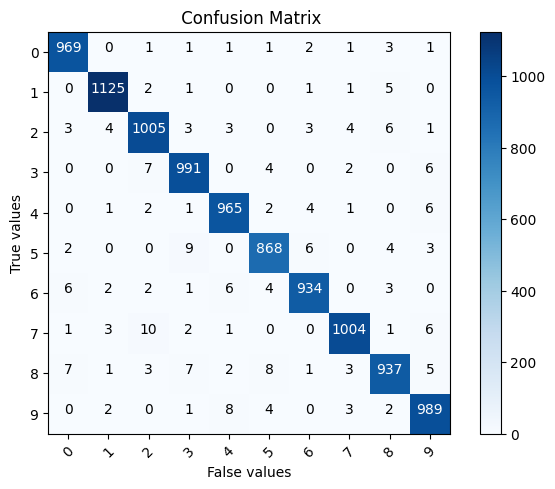

In [50]:
#All predictions to the array

x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()
p_test = np.array([])

for inputs, targets in test_loader:
    inputs = inputs.to(device)
    inputs = inputs.view(-1,784)
    
    #Forward pass
    outputs = model(inputs)
    
    #Predictions 
    _, predictions = torch.max(outputs, 1)
    
    #Update p_test
    p_test = np.concatenate((p_test, predictions.cpu().numpy()))
    
cm = confusion_matrix(y_test, p_test)
plot_confussion_matrix(cm, list(range(10)))
    